В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, f1_score
import joblib

In [2]:
raw_df = pd.read_csv('bank_customer/train.csv')
raw_df.head(5)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
raw_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [4]:
sub = pd.read_csv('bank_customer/sample_submission.csv')

In [5]:
sub.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [6]:
# Розбиття на train / validate
train_df, validation_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df['Exited']
)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [7]:
input_cols = list(raw_df.columns)[1:-1]
target_col = 'Exited'

In [8]:
input_cols

['CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [9]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [10]:
val_inputs = validation_df[input_cols].copy()
val_targets = validation_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [11]:
numeric_cols = train_df.select_dtypes(include='number').columns.tolist()
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()

In [12]:
numeric_cols

['id',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [13]:
categorical_cols

['Surname', 'Geography', 'Gender']

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               12000 non-null  int64  
 1   CustomerId       12000 non-null  float64
 2   Surname          12000 non-null  object 
 3   CreditScore      12000 non-null  float64
 4   Geography        12000 non-null  object 
 5   Gender           12000 non-null  object 
 6   Age              12000 non-null  float64
 7   Tenure           12000 non-null  float64
 8   Balance          12000 non-null  float64
 9   NumOfProducts    12000 non-null  float64
 10  HasCrCard        12000 non-null  float64
 11  IsActiveMember   12000 non-null  float64
 12  EstimatedSalary  12000 non-null  float64
 13  Exited           12000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.4+ MB


In [15]:
# Маємо 14 колонок, 3 з яких категоріальні. Пропущених даних в датасеті немає, тому нічого не заповнюємо. Колонки: id, CustomerId та Surname - нерелевантні, їх можна видалити.

In [16]:
# Стовпець Gender - бінарна категорія, тому можемо закодувати за допомогою 1 і 0

<Axes: xlabel='Gender', ylabel='Exited'>

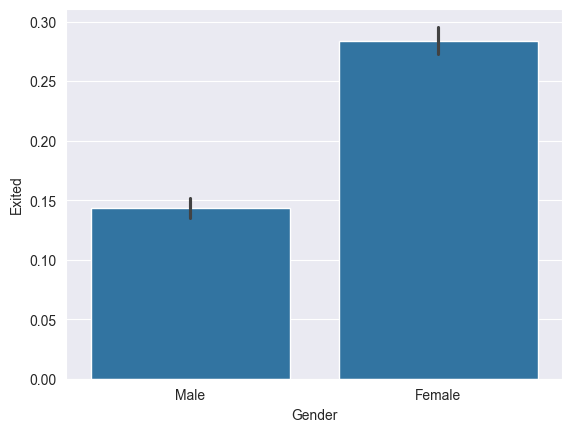

In [17]:
sns.barplot(data=train_df, x='Gender', y='Exited')

In [18]:
gender_codes = {'Male': 0, 'Female': 1}
train_inputs['Gender_Code'] = train_inputs['Gender'].map(gender_codes)
val_inputs['Gender_Code'] = val_inputs['Gender'].map(gender_codes)

In [19]:
train_inputs['Geography'].unique()

array(['France', 'Germany', 'Spain'], dtype=object)

In [20]:
# Колонка Geography має 3 унікальні значення, отже ми можемо виконати one-hot encoding

In [21]:
geography_enc = preprocessing.OneHotEncoder(handle_unknown="ignore", sparse_output=False)
geography_enc.fit(train_inputs[['Geography']])
geography_enc.categories_

[array(['France', 'Germany', 'Spain'], dtype=object)]

In [22]:
geography_one_hot = geography_enc.transform(train_inputs[['Geography']])
geography_one_hot

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]], shape=(12000, 3))

In [23]:
geography_one_hot_val = geography_enc.transform(validation_df[['Geography']])
geography_one_hot_val

array([[0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.]], shape=(3000, 3))

In [24]:
train_inputs[geography_enc.categories_[0]] = geography_one_hot
val_inputs[geography_enc.categories_[0]] = geography_one_hot_val

In [25]:
drop_cols = ['Gender', 'Geography', 'CustomerId', 'Surname']
train_inputs = train_inputs.drop(columns=drop_cols)
val_inputs = val_inputs.drop(columns=drop_cols)

In [26]:
y_train = train_df[target_col].copy()
y_val   = validation_df[target_col].copy()

In [27]:
scale_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

In [28]:
# В наших даних різні стовпці мають різні діапазони, скористаємось традиційним у таких випадках feature scaling

In [29]:
scaler = StandardScaler()
scaler.fit(train_inputs[scale_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [30]:
train_inputs[scale_cols] = scaler.transform(train_inputs[scale_cols])
val_inputs[scale_cols]   = scaler.transform(val_inputs[scale_cols])

In [31]:
train_inputs.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
7180,0.320187,-0.944682,-1.447264,1.475464,1.0,1.0,1.0,0.569450,0,1.0,0.0,0.0
10393,0.347838,0.161227,-1.087792,2.254434,1.0,1.0,0.0,0.603803,1,1.0,0.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,2.0,1.0,0.0,1.238026,0,0.0,1.0,0.0
3365,0.140460,2.495924,-1.806736,-0.717950,2.0,0.0,1.0,-1.457116,0,0.0,0.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,2.0,1.0,1.0,0.670629,0,1.0,0.0,0.0


In [32]:
val_inputs.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Code,France,Germany,Spain
6490,0.762592,1.021379,-1.447264,1.214543,4.0,1.0,1.0,-0.988144,0,0.0,1.0,0.0
3646,-0.910252,0.406985,-0.009376,-0.717950,2.0,1.0,1.0,-1.750392,0,1.0,0.0,0.0
5306,0.997620,0.038348,-1.087792,-0.717950,2.0,0.0,1.0,-0.022404,1,1.0,0.0,0.0
652,0.195761,0.652742,-0.368848,1.881867,1.0,0.0,1.0,-0.139723,1,1.0,0.0,0.0
2627,0.264887,-0.944682,-0.368848,-0.717950,2.0,1.0,0.0,0.563519,1,0.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [51]:
import pyarrow as pa
import pyarrow.parquet as pq

pq.write_table(
    pa.Table.from_pandas(train_inputs, preserve_index=False),
    "kaggle_files/train_inputs.parquet",
)

pq.write_table(
    pa.Table.from_pandas(val_inputs, preserve_index=False),
    "kaggle_files/val_inputs.parquet",
)

In [52]:
pq.write_table(
    pa.Table.from_pandas(train_targets.to_frame(name=target_col), preserve_index=False),
    "kaggle_files/train_targets.parquet",
)

pq.write_table(
    pa.Table.from_pandas(val_targets.to_frame(name=target_col), preserve_index=False),
    "kaggle_files/val_targets.parquet",
)

In [53]:
import os
os.listdir('kaggle_files')

['train_targets.parquet',
 'train_inputs.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [54]:
X_train = train_inputs.copy()
X_val   = val_inputs.copy()

y_train = train_targets.copy()
y_val   = val_targets.copy()

In [55]:
y_val.value_counts(normalize=True)

Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64

In [56]:
model = LogisticRegression(
    max_iter=2000,
    C=0.02,
    solver="lbfgs",
    class_weight="balanced",
    fit_intercept=True,
    tol=1e-6
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.02
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-06
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [57]:
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))

Accuracy: 0.8113333333333334
ROC-AUC: 0.8801563893271144


In [60]:
# У нас дані незбалансовані, 0 класу приблизно 80%, тому використовувати accuracy для оцінки класифікатора буде недоцільно.

In [61]:
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

In [62]:
confusion_matrix(train_targets, train_preds)

array([[7950, 1608],
       [ 484, 1958]])

In [63]:
confusion_matrix(val_targets, val_preds)

array([[1938,  452],
       [ 114,  496]])

In [64]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy {}: {:.2f}%".format(name, accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))

    return preds

In [65]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

Accuracy Training: 82.57%
Accuracy Validation: 81.13%


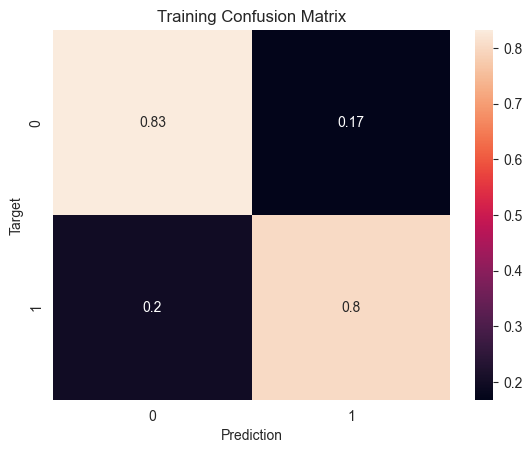

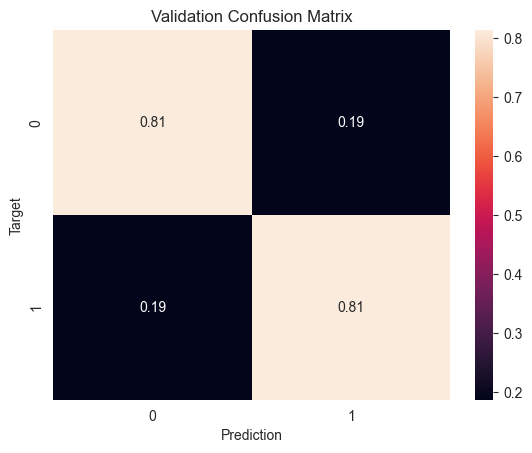

In [66]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

AUROC for Training: 0.88


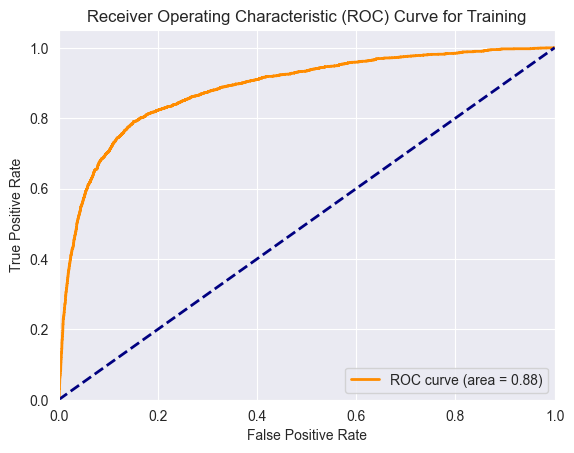

AUROC for Validation: 0.88


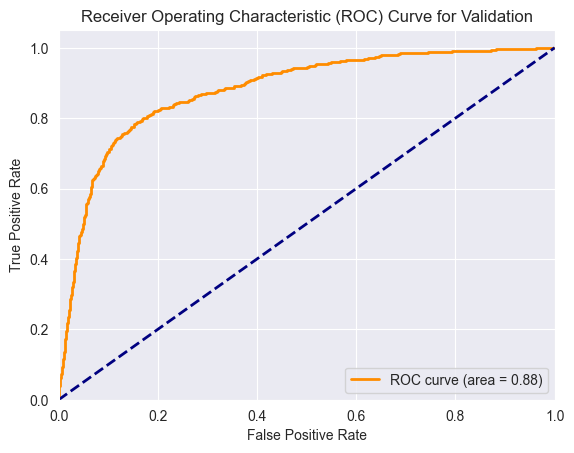

In [67]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [68]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}%")

In [69]:
get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.65%
F1 score Validation: 0.64%


In [70]:
# F1 на тренувальних даних 0.65, на валідаційних 0.64, падіння мінімальне. Модель досить добре балансує між знайти і не помилитись.
# ROC-AUC: ~0.88 - показник хорошої моделі

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [71]:
majority_class = y_train.value_counts().idxmax()

In [72]:
majority_train_targets = np.full_like(train_targets, fill_value=majority_class)
majority_val_targets = np.full_like(val_targets, fill_value=majority_class)

Accuracy Training (Majority class): 70.28%
Accuracy Validation (Majority class): 68.40%


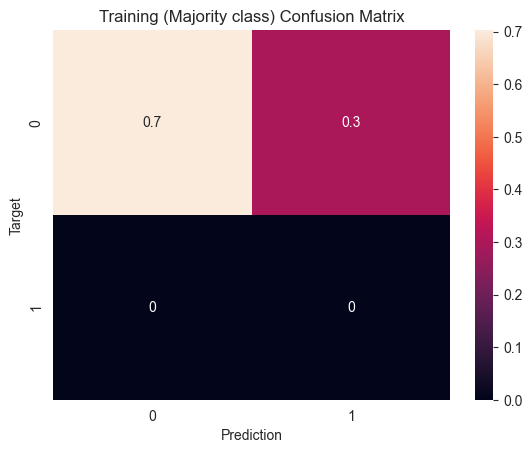

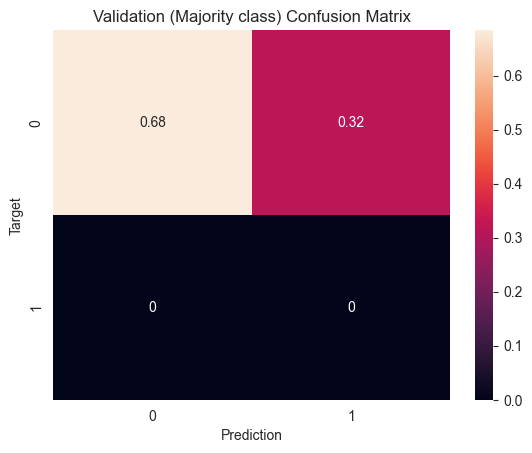

In [73]:
majority_train_preds = predict_and_plot(X_train, majority_train_targets, 'Training (Majority class)')
majority_val_preds = predict_and_plot(X_val, majority_val_targets, 'Validation (Majority class)')

In [ ]:
# Accuracy на мажоритарному класі становить близько 70% на тренувальних даних, та 68 на валідаційних, показник значно нижчий за модель із п. 6. Наша модель хороша, значно перевищує бейслайн за accuracy (бейслайн взагалі не вміє знаходити міноритарний клас)

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [315]:
# Save the trained model & load it back
churn_predict = {'model': model, 'scaler': scaler, 'scale_cols': scale_cols, 'target_col': target_col, 'drop_cols': drop_cols,
               'categorical_cols': categorical_cols, 'gender_codes': gender_codes}
joblib.dump(churn_predict, 'churn_predict.joblib')
churn_predict_2 = joblib.load('churn_predict.joblib')

In [316]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

best = (-1, None)
for C in [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]:
    model = LogisticRegression(
        C=C,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000,
        tol=1e-6,
    )
    model.fit(X_train, y_train)
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    print(C, auc)
    if auc > best[0]:
        best = (auc, C)

print("BEST:", best)

0.005 0.8792365731531654
0.01 0.8799972563275944
0.02 0.8801563893271144
0.05 0.8801200356677414
0.1 0.8800411550860827
0.2 0.8799602167501201
0.5 0.8799629604225255
1 0.8799540434872076
BEST: (0.8801563893271144, 0.02)


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [317]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, scale_cols, to_drop_cols, gender_codes, input_df: pd.DataFrame, model):
    X_input = input_df.copy()
    X_input['Gender_Code'] = X_input['Gender'].map(gender_codes)
    geo_one_hot = encoder.transform(X_input[['Geography']])
    X_input = X_input.drop(columns=to_drop_cols + ['id'])
    X_input[encoder.categories_[0]] = geo_one_hot
    X_input[scale_cols] = scaler.transform(X_input[scale_cols])

    pred = model.predict(X_input)[0]
    proba = model.predict_proba(X_input)[0]
    class1_idx = np.where(model.classes_ == 1)[0][0]
    prob_exited_1 = float(proba[class1_idx])
    
    return prob_exited_1, pred

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [318]:
test_raw_df = pd.read_csv('bank_customer/test.csv')

In [319]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [320]:
predict_raw_df(scaler, geography_enc, scale_cols, drop_cols, gender_codes, test_raw_df[:10], churn_predict_2['model'])

(0.23407143689536156, np.float64(0.0))

In [321]:
probs = []
for _, row in test_raw_df.iterrows():
    prob1, pred = predict_raw_df(
        scaler=scaler,
        encoder=geography_enc,
        scale_cols=scale_cols,
        to_drop_cols=drop_cols,
        gender_codes=gender_codes,
        input_df=row.to_frame().T,
        model=model
    )
    probs.append(prob1)

test_raw_df["Exited"] = probs

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [322]:
sample_sub = pd.read_csv("bank_customer/sample_submission.csv")

submission = sample_sub.copy()
submission["Exited"] = test_raw_df["Exited"].values
submission.to_csv("bank_customer/submission_log_reg.csv", index=False)

In [323]:
submission.head(5)

,id,Exited
0,15000,0.220606
1,15001,0.135570
2,15002,0.415419
3,15003,0.475771
4,15004,0.210373
